# Phishing Email Detection — Core Model Builder**CECS 458 — Team 10 — Phase 3**This notebook trains a phishing-email classifier and saves two files (`model.pkl` and `vectorizer.pkl`) that the UI teammate will plug into Streamlit.**How to use this notebook:**1. Runtime → Change runtime type → **T4 GPU** (optional but faster)2. Run cells **top to bottom, one at a time**3. If a cell fails, read the error, fix it, and re-run that cell**What you'll need before you start:**- A Kaggle account- Your `kaggle.json` API key file (from kaggle.com → Settings → API → Create New Token)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1 — Install librariesRuns for about 30 seconds. You'll see a bunch of install output — that's normal.

In [2]:
!pip install kagglehub joblib scikit-learn pandas numpy matplotlib seaborn --quiet
print("Libraries installed.")

Libraries installed.


## Step 2 — Paste your Kaggle API tokenOn kaggle.com → Settings → API, you'll see an **API TOKEN** box with a long string starting with `KGAT_`. Copy that whole string.When you run the cell below, a text box will pop up asking for it. Paste it in and press Enter.**Your token will not be printed or saved in the notebook** — it only lives in memory for this session.

In [3]:
import os, getpass

# Securely prompt for the token (won't show on screen)
token = getpass.getpass('Paste your Kaggle API token (starts with KGAT_): ').strip()

# Set it as an environment variable — this is what kagglehub looks for
os.environ['KAGGLE_API_TOKEN'] = token

# Also write a kaggle.json for backward compatibility with some libraries
# (splits the KGAT token into the legacy username/key format Kaggle accepts)
import json
os.makedirs('/root/.config/kaggle', exist_ok=True)
# Newer kagglehub just uses KAGGLE_API_TOKEN directly — no json needed
print("Kaggle token set.")
print(f"Token starts with: {token[:8]}...  (length: {len(token)})")

Paste your Kaggle API token (starts with KGAT_): ··········
Kaggle token set.
Token starts with: KGAT_8a9...  (length: 37)


## Step 3 — Mount Google Drive (optional but recommended)This gives your trained model a permanent home so you don't lose it when Colab disconnects. A popup will ask you to sign in with your Google account — accept it.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Create a folder in your Drive for this project
os.makedirs('/content/drive/MyDrive/phishing_detector', exist_ok=True)
print("Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


## Step 4 — Download the two datasetsThis pulls both Kaggle datasets into Colab. Takes 1–3 minutes depending on connection.The two datasets are:- **naserabdullahalam/phishing-email-dataset** — large corpus of real phishing + legitimate emails- **francescogreco97/human-llm-generated-phishing-legitimate-emails** — AI-generated phishing (addresses modern threats)

In [5]:
import kagglehub

path1 = kagglehub.dataset_download('naserabdullahalam/phishing-email-dataset')
path2 = kagglehub.dataset_download('francescogreco97/human-llm-generated-phishing-legitimate-emails')

print("Dataset 1 location:", path1)
print("Dataset 1 files:", os.listdir(path1))
print()
print("Dataset 2 location:", path2)
print("Dataset 2 files:", os.listdir(path2))

100%|██████████| 77.1M/77.1M [00:07<00:00, 11.5MB/s]

Extracting files...


100%|██████████| 1.16M/1.16M [00:01<00:00, 994kB/s]

Extracting files...
Dataset 1 location: /root/.cache/kagglehub/datasets/naserabdullahalam/phishing-email-dataset/versions/1
Dataset 1 files: ['SpamAssasin.csv', 'CEAS_08.csv', 'Nazario.csv', 'phishing_email.csv', 'Enron.csv', 'Nigerian_Fraud.csv', 'Ling.csv']

Dataset 2 location: /root/.cache/kagglehub/datasets/francescogreco97/human-llm-generated-phishing-legitimate-emails/versions/1
Dataset 2 files: ['llm-generated', 'human-generated']


**Look at the output above.** You'll see a list of `.csv` filenames. Note them down — the next cell needs them.

In [6]:
# Diagnostic: show EVERYTHING in path2, including subfolders
for root, dirs, fnames in os.walk(path2):
    for f in fnames:
        full = os.path.join(root, f)
        size_mb = os.path.getsize(full) / 1e6
        print(f"{size_mb:7.2f} MB  {full}")

   0.65 MB  /root/.cache/kagglehub/datasets/francescogreco97/human-llm-generated-phishing-legitimate-emails/versions/1/llm-generated/legit.csv
   0.66 MB  /root/.cache/kagglehub/datasets/francescogreco97/human-llm-generated-phishing-legitimate-emails/versions/1/llm-generated/phishing.csv
   4.37 MB  /root/.cache/kagglehub/datasets/francescogreco97/human-llm-generated-phishing-legitimate-emails/versions/1/human-generated/legit.csv
   1.34 MB  /root/.cache/kagglehub/datasets/francescogreco97/human-llm-generated-phishing-legitimate-emails/versions/1/human-generated/phishing.csv


## Step 5 — Load and inspect the datasetsThis cell auto-detects the right CSV files and shows you what's inside.

In [9]:
import pandas as pd

# ─── Dataset 1 — already worked, keep as-is ────────────────────────────────
csvs1 = [f for f in os.listdir(path1) if f.endswith('.csv')]
preferred = ['phishing_email.csv', 'Phishing_Email.csv', 'phishing_emails.csv']
file1 = next((f for f in preferred if f in csvs1), csvs1[0])
df1_raw = pd.read_csv(os.path.join(path1, file1))
print(f"Dataset 1: {file1}  →  {df1_raw.shape}  cols: {list(df1_raw.columns)}")

# ─── Dataset 2 — robust loader that survives malformed CSV rows ───
import pandas as pd, os

def robust_read(path):
    """Try several parsing strategies until one works."""
    # Strategy 1: default
    try:
        return pd.read_csv(path)
    except Exception:
        pass
    # Strategy 2: python engine + skip bad lines (most forgiving)
    try:
        return pd.read_csv(path, engine='python', on_bad_lines='skip')
    except Exception:
        pass
    # Strategy 3: treat as quoted, python engine
    return pd.read_csv(path, engine='python', on_bad_lines='skip', quoting=1)

dfs = []
for source_folder in ['human-generated', 'llm-generated']:
    for label_name, label_val in [('legit.csv', 0), ('phishing.csv', 1)]:
        full = os.path.join(path2, source_folder, label_name)
        tmp = robust_read(full)
        tmp['label'] = label_val
        tmp['source'] = source_folder
        dfs.append(tmp)
        print(f"  {source_folder}/{label_name}: {len(tmp)} rows → label={label_val}")

df2_raw = pd.concat(dfs, ignore_index=True)
print(f"\nDataset 2 total: {df2_raw.shape}, cols: {list(df2_raw.columns)}")
print("Label distribution:")
print(df2_raw.groupby(['source', 'label']).size())

Dataset 1: phishing_email.csv  →  (82486, 2)  cols: ['text_combined', 'label']
  human-generated/legit.csv: 1000 rows → label=0
  human-generated/phishing.csv: 1000 rows → label=1
  llm-generated/legit.csv: 1000 rows → label=0
  llm-generated/phishing.csv: 595 rows → label=1

Dataset 2 total: (3595, 9), cols: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label', 'source', 'text']
Label distribution:
source           label
human-generated  0        1000
                 1        1000
llm-generated    0        1000
                 1         595
dtype: int64


## Step 6 — Normalize both datasets into a unified formatEach dataset has different column names. This cell figures out which column is the email text and which is the label, then merges them into one clean DataFrame with just two columns: `text` and `label` (1 = phishing, 0 = legitimate).

In [10]:
def find_text_column(df):
    """Find the column most likely to contain email text."""
    candidates = ['text', 'Email Text', 'email', 'body', 'content', 'message']
    for c in candidates:
        if c in df.columns:
            return c
    # Fallback: pick the column with the longest average string length
    str_cols = df.select_dtypes(include='object').columns
    return max(str_cols, key=lambda c: df[c].astype(str).str.len().mean())

def find_label_column(df):
    """Find the column most likely to be the label."""
    candidates = ['label', 'Email Type', 'class', 'type', 'category', 'is_phishing']
    for c in candidates:
        if c in df.columns:
            return c
    # Fallback: a column with exactly 2 unique values
    for c in df.columns:
        if df[c].nunique() == 2:
            return c
    raise ValueError("Can't find label column — inspect df manually")

def normalize(df, name):
    tcol = find_text_column(df)
    lcol = find_label_column(df)
    print(f"{name}: text='{tcol}', label='{lcol}'")
    print(f"  Unique label values: {df[lcol].unique()[:10]}")

    out = pd.DataFrame({
        'text':  df[tcol].astype(str),
        'label_raw': df[lcol]
    })
    # Map any labeling scheme to 1 = phishing, 0 = legitimate
    def to_binary(v):
        if isinstance(v, (int, float)):
            return int(v)      # already numeric 0/1
        s = str(v).lower().strip()
        if any(k in s for k in ['phish', 'spam', 'fraud', 'malicious']):
            return 1
        if any(k in s for k in ['safe', 'legit', 'ham', 'normal']):
            return 0
        return None
    out['label'] = out['label_raw'].apply(to_binary)
    out = out.dropna(subset=['label'])
    out['label'] = out['label'].astype(int)
    return out[['text', 'label']]

df1 = normalize(df1_raw, "Dataset 1")
df2 = normalize(df2_raw, "Dataset 2")

print(f"\nDataset 1: {len(df1)} rows  |  Phishing: {df1['label'].sum()}  Legit: {(df1['label']==0).sum()}")
print(f"Dataset 2: {len(df2)} rows  |  Phishing: {df2['label'].sum()}  Legit: {(df2['label']==0).sum()}")

Dataset 1: text='text_combined', label='label'
  Unique label values: [0 1]
Dataset 2: text='text', label='label'
  Unique label values: [0 1]

Dataset 1: 82486 rows  |  Phishing: 42891  Legit: 39595
Dataset 2: 3595 rows  |  Phishing: 1595  Legit: 2000


## Step 7 — Merge and clean

In [11]:
df = pd.concat([df1, df2], ignore_index=True)

# Remove duplicates and very short junk
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
df = df[df['text'].str.len() > 20].reset_index(drop=True)

print(f"Total merged rows: {len(df)}")
print(f"Phishing: {df['label'].sum()} ({df['label'].mean()*100:.1f}%)")
print(f"Legitimate: {(df['label']==0).sum()} ({(df['label']==0).mean()*100:.1f}%)")

Total merged rows: 83106
Phishing: 42895 (51.6%)
Legitimate: 40211 (48.4%)


## Step 8 — PII Scrubbing (privacy step)Removes personal info from emails before the model sees them. Replaces emails, phone numbers, URLs, and IP addresses with generic tags. This is the privacy feature you promised in the Phase 2 feasibility report.

In [12]:
import re

def scrub_pii(text: str) -> str:
    text = re.sub(r'[\w.+-]+@[\w-]+\.[a-zA-Z]{2,}', '<EMAIL>', text)
    text = re.sub(r'(\+?1[\s.-]?)?\(?\d{3}\)?[\s.-]\d{3}[\s.-]\d{4}', '<PHONE>', text)
    text = re.sub(r'https?://\S+|www\.\S+', '<URL>', text)
    text = re.sub(r'\b\d{1,3}(?:\.\d{1,3}){3}\b', '<IP>', text)
    return text.strip()

df['text_clean'] = df['text'].apply(scrub_pii)

# Count how much PII was removed (you'll need these numbers for the report)
stats = {
    'emails_removed': df['text_clean'].str.count('<EMAIL>').sum(),
    'urls_removed':   df['text_clean'].str.count('<URL>').sum(),
    'phones_removed': df['text_clean'].str.count('<PHONE>').sum(),
    'ips_removed':    df['text_clean'].str.count('<IP>').sum(),
}
print("PII Scrubbing Stats:")
for k, v in stats.items():
    print(f"  {k}: {v:,}")

print("\nExample scrubbed email:")
print(df['text_clean'].iloc[0][:300])

PII Scrubbing Stats:
  emails_removed: 53
  urls_removed: 934
  phones_removed: 10,422
  ips_removed: 0

Example scrubbed email:
hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls


## Step 9 — Split data and run TF-IDFTF-IDF converts text into numbers the model can understand. Each word gets a score based on how distinctive it is. Words like "urgent" or "verify" score high because they show up disproportionately in phishing.**Important:** We fit the vectorizer on the training data only, never on the test data. Otherwise we'd be cheating.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['text_clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),      # single words AND two-word phrases like "click here"
    sublinear_tf=True,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)   # FIT ONLY on train
X_test_tfidf  = vectorizer.transform(X_test)        # transform test (no fit)

print(f"Train set:  {X_train_tfidf.shape}")
print(f"Test set:   {X_test_tfidf.shape}")
print(f"Vocabulary: {len(vectorizer.vocabulary_):,} terms")

Train set:  (66484, 10000)
Test set:   (16622, 10000)
Vocabulary: 10,000 terms


## Step 10 — Train Logistic Regression and Random ForestTakes 1–4 minutes depending on dataset size. Random Forest is the slow one.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced')
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')

print("Training Logistic Regression...")
lr.fit(X_train_tfidf, y_train)
print("  Done.")

print("Training Random Forest (this takes longer)...")
rf.fit(X_train_tfidf, y_train)
print("  Done.")

Training Logistic Regression...
  Done.
Training Random Forest (this takes longer)...
  Done.


## Step 11 — Evaluate both modelsShows accuracy, precision, recall, F1 for each. The confusion matrix shows where each model got things wrong.


  Logistic Regression  —  weighted F1: 0.9872
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      8043
    Phishing       0.99      0.99      0.99      8579

    accuracy                           0.99     16622
   macro avg       0.99      0.99      0.99     16622
weighted avg       0.99      0.99      0.99     16622



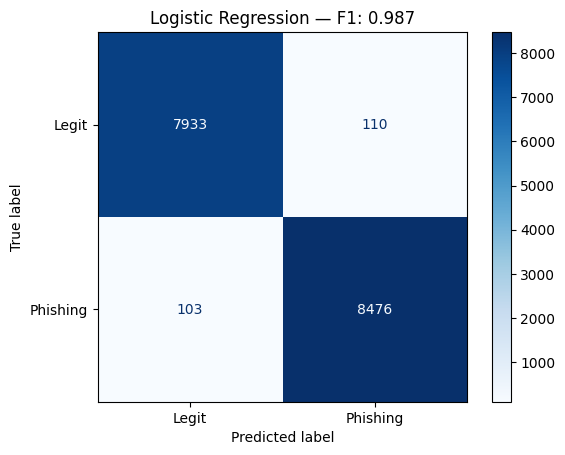


  Random Forest  —  weighted F1: 0.9868
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      8043
    Phishing       0.99      0.99      0.99      8579

    accuracy                           0.99     16622
   macro avg       0.99      0.99      0.99     16622
weighted avg       0.99      0.99      0.99     16622



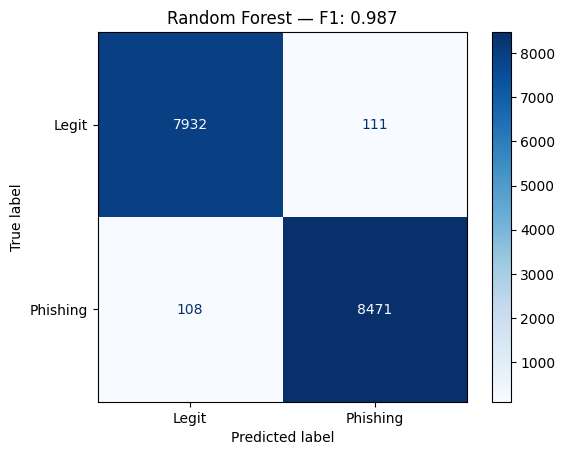


>>> Best model: Logistic Regression (F1 = 0.9872)


In [15]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

results = {}

for name, clf in [('Logistic Regression', lr), ('Random Forest', rf)]:
    preds = clf.predict(X_test_tfidf)
    f1 = f1_score(y_test, preds, average='weighted')
    results[name] = {'model': clf, 'f1': f1, 'preds': preds}

    print(f"\n{'='*60}")
    print(f"  {name}  —  weighted F1: {f1:.4f}")
    print('='*60)
    print(classification_report(y_test, preds, target_names=['Legitimate', 'Phishing']))

    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Phishing'])
    disp.plot(cmap='Blues')
    plt.title(f'{name} — F1: {f1:.3f}')
    plt.show()

# Pick the winner
best_name = max(results, key=lambda k: results[k]['f1'])
best_model = results[best_name]['model']
print(f"\n>>> Best model: {best_name} (F1 = {results[best_name]['f1']:.4f})")

## Step 12 — Save model.pkl and vectorizer.pklThese are the two files the UI teammate needs.

In [16]:
import joblib

# Save in the local project folder (for the repo)
os.makedirs('model/artifacts', exist_ok=True)
joblib.dump(best_model,  'model/artifacts/model.pkl')
joblib.dump(vectorizer,  'model/artifacts/vectorizer.pkl')

# Save a backup copy to Drive so you don't lose it
joblib.dump(best_model,  '/content/drive/MyDrive/phishing_detector/model.pkl')
joblib.dump(vectorizer,  '/content/drive/MyDrive/phishing_detector/vectorizer.pkl')

print("Saved:")
print("  model/artifacts/model.pkl")
print("  model/artifacts/vectorizer.pkl")
print("  /content/drive/MyDrive/phishing_detector/  (backup)")

Saved:
  model/artifacts/model.pkl
  model/artifacts/vectorizer.pkl
  /content/drive/MyDrive/phishing_detector/  (backup)


In [17]:
from google.colab import files
files.download('model/artifacts/model.pkl')
files.download('model/artifacts/vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 13 — Integration testThis simulates exactly what the UI teammate's app will do when a user pastes an email. **If this cell works, you're done.**

In [18]:
# Reload from disk — same as the UI will do
m = joblib.load('model/artifacts/model.pkl')
v = joblib.load('model/artifacts/vectorizer.pkl')

test_emails = [
    "URGENT: Your account has been compromised. Click here immediately to verify your identity or your account will be suspended within 24 hours.",
    "Hi team, attaching the notes from this morning's meeting. Let me know if you have any questions before Friday's deadline. Thanks!",
    "Dear customer, we noticed unusual activity on your PayPal account. Please confirm your password at http://paypa1-verify.com to secure your account."
]

for i, email in enumerate(test_emails, 1):
    clean = scrub_pii(email)
    pred = m.predict(v.transform([clean]))[0]
    prob = m.predict_proba(v.transform([clean]))[0][1]
    verdict = 'PHISHING' if pred == 1 else 'LEGITIMATE'
    print(f"\nEmail {i}: \"{email[:60]}...\"")
    print(f"  Verdict: {verdict}  (phishing confidence: {prob:.1%})")


Email 1: "URGENT: Your account has been compromised. Click here immedi..."
  Verdict: PHISHING  (phishing confidence: 99.7%)

Email 2: "Hi team, attaching the notes from this morning's meeting. Le..."
  Verdict: LEGITIMATE  (phishing confidence: 0.1%)

Email 3: "Dear customer, we noticed unusual activity on your PayPal ac..."
  Verdict: PHISHING  (phishing confidence: 91.9%)


## Step 14 — Top 20 phishing indicator words (for the PM's report)Only runs if your best model was Logistic Regression. Skip if it was Random Forest.

In [19]:
if best_name == 'Logistic Regression':
    import numpy as np
    feature_names = vectorizer.get_feature_names_out()
    coefs = best_model.coef_[0]
    top20 = pd.Series(coefs, index=feature_names).nlargest(20)
    print("Top 20 words/phrases that signal PHISHING:")
    print(top20.to_string())
else:
    # For Random Forest, use feature importances
    import numpy as np
    feature_names = vectorizer.get_feature_names_out()
    importances = best_model.feature_importances_
    top20 = pd.Series(importances, index=feature_names).nlargest(20)
    print("Top 20 words/phrases the model paid most attention to:")
    print(top20.to_string())

Top 20 words/phrases that signal PHISHING:
josemonkeyorg    5.267605
0300             5.066699
2004             4.861505
http             4.606047
life             4.600561
love             4.401017
money            4.373499
com              4.298055
2016             4.246823
click            3.924428
account          3.905599
2005             3.808888
2017             3.788917
remove           3.693364
2018             3.668122
2019             3.609766
watches          3.482428
site             3.402174
meds             3.316592
bank             3.300239


## Step 15 — Summary block for the Project ManagerCopy-paste the printed output of this cell into your team's progress report.

In [20]:
phishing_f1 = classification_report(y_test, results[best_name]['preds'], output_dict=True)['1']['f1-score']

summary = f"""
=== MODEL BUILDER SUMMARY — PHASE 3 ===

DATASETS
  Source 1 (naserabdullahalam):         {len(df1):,} rows
  Source 2 (francescogreco97, LLM-gen): {len(df2):,} rows
  Merged + deduplicated:                {len(df):,} rows
  Class balance: {df['label'].mean()*100:.1f}% phishing, {(df['label']==0).mean()*100:.1f}% legitimate

PII SCRUBBING (privacy step)
  Emails removed: {stats['emails_removed']:,}
  URLs removed:   {stats['urls_removed']:,}
  Phones removed: {stats['phones_removed']:,}
  IPs removed:    {stats['ips_removed']:,}

MODEL COMPARISON (weighted F1 on test set)
  Logistic Regression: {results['Logistic Regression']['f1']:.4f}
  Random Forest:       {results['Random Forest']['f1']:.4f}
  Selected model:      {best_name}
  F1 on phishing class: {phishing_f1:.4f}

PHASE 2 FEEDBACK RESPONSE
  The francescogreco97 dataset was explicitly included to cover modern
  AI/LLM-generated phishing, addressing the professor's feedback about
  traditional corpora missing contemporary threats.

NEXT STEPS
  - Hand off model/artifacts/model.pkl and vectorizer.pkl to UI Integrator
  - SHAP explainability is planned as a bonus enhancement
"""

print(summary)


=== MODEL BUILDER SUMMARY — PHASE 3 ===

DATASETS
  Source 1 (naserabdullahalam):         82,486 rows
  Source 2 (francescogreco97, LLM-gen): 3,595 rows
  Merged + deduplicated:                83,106 rows
  Class balance: 51.6% phishing, 48.4% legitimate

PII SCRUBBING (privacy step)
  Emails removed: 53
  URLs removed:   934
  Phones removed: 10,422
  IPs removed:    0

MODEL COMPARISON (weighted F1 on test set)
  Logistic Regression: 0.9872
  Random Forest:       0.9868
  Selected model:      Logistic Regression
  F1 on phishing class: 0.9876

PHASE 2 FEEDBACK RESPONSE
  The francescogreco97 dataset was explicitly included to cover modern
  AI/LLM-generated phishing, addressing the professor's feedback about
  traditional corpora missing contemporary threats.

NEXT STEPS
  - Hand off model/artifacts/model.pkl and vectorizer.pkl to UI Integrator
  - SHAP explainability is planned as a bonus enhancement



---## You're done!Send your UI teammate these two files:- `model/artifacts/model.pkl`- `model/artifacts/vectorizer.pkl`Plus the `scrub_pii` function from Step 8 (they need to run the same scrubbing on user input before prediction).If the integration test in Step 13 prints "PHISHING" with high confidence for the urgent email and "LEGITIMATE" for the meeting notes, you've succeeded.